[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kuffmode/OHBM-Example-2026/blob/main/Reservoir_Tutorials/experiment_2_rc_tuned_mc.ipynb)

# Experiment 2: Memory Capacity — Hyperparameter Tuning

In Experiment 1 we evaluated an ESN with arbitrarily chosen parameters. Here we ask: **how much does parameter choice matter?**

We perform a grid search over three parameters: `spectral_radius`, `sparsity`, and `input_scaling`, while keeping the reservoir size and other parameters fixed. Every configuration is evaluated over `N_RUNS` independent random seeds (both data and reservoir weights), and the mean test MC is used to rank configurations. The best configuration is then re-run once to produce the same diagnostic plots as Experiment 1, allowing a direct visual comparison.

## 0 · Setup

In [1]:
!pip install echoes --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 3.5 MB/s eta 0:00:00


In [2]:
import itertools
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor

warnings.filterwarnings('ignore')
rng_global = np.random.default_rng(42)
print('All imports OK.')

All imports OK.


## 1 · Fixed parameters and grid to search

In [3]:
# ── Fixed (not searched)
SEQ_LEN      = 3000
TRAIN_FRAC   = 0.7
NUM_DELAYS   = 40
N_RESERVOIR  = 100
BIAS         = 0.0
RIDGE_ALPHA  = 1e-10
N_TRANSIENT  = 100

# ── Grid search settings
PARAM_GRID = {
    'spectral_radius' : [0.5, 0.7, 0.9, 0.95, 0.99],
    'sparsity'        : [0.8, 0.9, 0.95, 0.975],
    'input_scaling'   : [0.05, 0.10, 0.15, 0.20, 0.30],
}
N_RUNS    = 5    # random seeds averaged per configuration
BASE_SEED = 0

# ── Diagnostic plot settings
N_NEURONS_PLOT = 10
PLOT_LAG       = 5
PLOT_WINDOW    = 200

## 2 · Helper functions

In [4]:
def generate_mc_data(seq_len, num_delays, seed=None):
    rng = np.random.default_rng(seed)
    u   = rng.standard_normal(seq_len)
    y   = np.zeros((seq_len, num_delays))
    for k in range(num_delays):
        y[k + 1:, k] = u[:seq_len - k - 1]
    return u.reshape(-1, 1), y


def memory_capacity(y_true, y_pred):
    """Sum of squared Pearson r across lag dimensions (transient already removed)."""
    r2_per_lag = np.array([
        pearsonr(y_true[:, k], y_pred[:, k])[0] ** 2
        for k in range(y_true.shape[1])
    ])
    return float(r2_per_lag.sum()), r2_per_lag


def evaluate_esn(spectral_radius, sparsity, input_scaling, data_seed, esn_seed,
                 store_states=False):
    """Single ESN run; returns (train_mc, test_mc) or (nan, nan) on failure."""
    try:
        X, y = generate_mc_data(SEQ_LEN, NUM_DELAYS, seed=data_seed)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, train_size=TRAIN_FRAC, shuffle=False
        )

        rng_win = np.random.default_rng(esn_seed)
        W_in = rng_win.uniform(-1.0, 1.0, size=(N_RESERVOIR, 1)) * float(input_scaling)

        esn = ESNRegressor(
            n_reservoir        = N_RESERVOIR,
            spectral_radius    = float(spectral_radius),
            sparsity           = sparsity,
            W_in               = W_in,
            input_scaling      = None,
            bias               = 0.0,
            noise              = 0.0,
            fit_only_states    = True,
            n_transient        = N_TRANSIENT,
            regression_method  = 'ridge',
            ridge_alpha        = RIDGE_ALPHA,
            random_state       = int(esn_seed),
            store_states_train = store_states,
            store_states_pred  = store_states,
        )

        esn.fit(X_train, y_train)
        y_pred_test = esn.predict(X_test)

        if not np.isfinite(y_pred_test).all():
            return np.nan, np.nan, None, None

        t = N_TRANSIENT
        train_mc, _ = memory_capacity(y_train[t:], esn.training_prediction_[t:])
        test_mc,  _ = memory_capacity(y_test[t:],  y_pred_test[t:])

        return train_mc, test_mc, esn, W_in

    except Exception:
        return np.nan, np.nan, None, None

## 3 · Grid search

In [5]:
keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*[PARAM_GRID[k] for k in keys]))
seed_pairs = [(BASE_SEED + i, BASE_SEED + 100 + i) for i in range(N_RUNS)]

results = []
n_total = len(combos)
t0 = time.time()

print(f'Grid search: {n_total} configurations × {N_RUNS} runs each')
print('=' * 68)

for idx, combo in enumerate(combos):
    params       = dict(zip(keys, combo))
    train_scores = []
    test_scores  = []

    for data_seed, esn_seed in seed_pairs:
        tr, te, _, _ = evaluate_esn(**params, data_seed=data_seed, esn_seed=esn_seed)
        if np.isfinite(tr) and np.isfinite(te):
            train_scores.append(tr)
            test_scores.append(te)

    mean_train = float(np.mean(train_scores)) if train_scores else np.nan
    mean_test  = float(np.mean(test_scores))  if test_scores  else np.nan
    std_test   = float(np.std(test_scores))   if test_scores  else np.nan

    results.append({
        **params,
        'mean_train_mc' : mean_train,
        'mean_test_mc'  : mean_test,
        'std_test_mc'   : std_test,
        'all_test_mcs'  : test_scores,
        'n_valid_runs'  : len(test_scores),
    })

    elapsed = time.time() - t0
    eta     = elapsed / (idx + 1) * (n_total - idx - 1)
    print(
        f'[{idx+1:3d}/{n_total}]  '
        + '  '.join(f'{k}={v}' for k, v in params.items())
        + f'  →  test MC {mean_test:.4f} ± {std_test:.4f}'
        + f'  (ETA {eta:.0f}s)'
    )

results.sort(
    key=lambda r: r['mean_test_mc'] if np.isfinite(r['mean_test_mc']) else -np.inf,
    reverse=True
)

Grid search: 100 configurations × 5 runs each
[  1/100]  spectral_radius=0.5  sparsity=0.8  input_scaling=0.05  →  test MC 15.2592 ± 0.4579  (ETA 628s)
[  2/100]  spectral_radius=0.5  sparsity=0.8  input_scaling=0.1  →  test MC 13.6257 ± 0.2154  (ETA 382s)
[  3/100]  spectral_radius=0.5  sparsity=0.8  input_scaling=0.15  →  test MC 12.4140 ± 0.1514  (ETA 304s)
[  4/100]  spectral_radius=0.5  sparsity=0.8  input_scaling=0.2  →  test MC 11.5347 ± 0.1885  (ETA 248s)
[  5/100]  spectral_radius=0.5  sparsity=0.8  input_scaling=0.3  →  test MC 10.2297 ± 0.2169  (ETA 220s)
[  6/100]  spectral_radius=0.5  sparsity=0.9  input_scaling=0.05  →  test MC 15.1167 ± 0.5589  (ETA 201s)
[  7/100]  spectral_radius=0.5  sparsity=0.9  input_scaling=0.1  →  test MC 13.5251 ± 0.5401  (ETA 184s)
[  8/100]  spectral_radius=0.5  sparsity=0.9  input_scaling=0.15  →  test MC 12.3846 ± 0.4823  (ETA 168s)
[  9/100]  spectral_radius=0.5  sparsity=0.9  input_scaling=0.2  →  test MC 11.4889 ± 0.4128  (ETA 155s)
[ 10/

## 4 · Results table

In [6]:
print('\n' + '=' * 75)
print(f"{'Rank':>4}  {'sr':>6}  {'sparsity':>8}  {'in_scl':>6}  "
      f"{'train_MC':>10}  {'test_MC':>9}  {'±std':>7}  {'runs':>4}")
print('-' * 75)
for rank, r in enumerate(results[:15], 1):
    print(
        f"{rank:4d}  {r['spectral_radius']:6.2f}  {r['sparsity']:8.3f}  "
        f"{r['input_scaling']:6.2f}  "
        f"{r['mean_train_mc']:10.4f}  {r['mean_test_mc']:9.4f}  "
        f"{r['std_test_mc']:7.4f}  {r['n_valid_runs']:4d}"
    )
print('=' * 75)

best = results[0]
print(f"\nBest configuration:")
for k in keys:
    print(f"  {k:20s} = {best[k]}")
print(f"  mean test MC         = {best['mean_test_mc']:.4f} ± {best['std_test_mc']:.4f}")
print(f"  individual runs      = {[round(v, 3) for v in best['all_test_mcs']]}")


Rank      sr  sparsity  in_scl    train_MC    test_MC     ±std  runs
---------------------------------------------------------------------------
   1    0.95     0.800    0.05     31.1434    30.0556   2.2557     5
   2    0.99     0.800    0.05     30.6463    29.4984   2.4379     5
   3    0.95     0.900    0.05     30.3323    29.1023   1.8963     5
   4    0.99     0.900    0.05     29.7169    28.3875   1.5991     5
   5    0.90     0.800    0.05     29.4840    28.3337   1.9612     5
   6    0.90     0.900    0.05     29.0693    27.7711   1.8795     5
   7    0.99     0.950    0.05     27.6534    26.4481   0.8072     5
   8    0.95     0.950    0.05     27.6643    26.2835   1.1393     5
   9    0.99     0.800    0.10     26.9757    25.3895   2.0512     5
  10    0.95     0.800    0.10     26.7272    25.2280   1.7014     5
  11    0.90     0.950    0.05     26.1958    24.7792   1.1267     5
  12    0.99     0.900    0.10     26.2228    24.5844   1.5331     5
  13    0.95     0.900    

## 5 · Diagnostic plots for the best configuration

We re-run the best configuration once with a held-out seed to produce the same six-panel figure as Experiment 1.

Best config (seed 999)  →  train MC = 31.3082  |  test MC = 30.3678


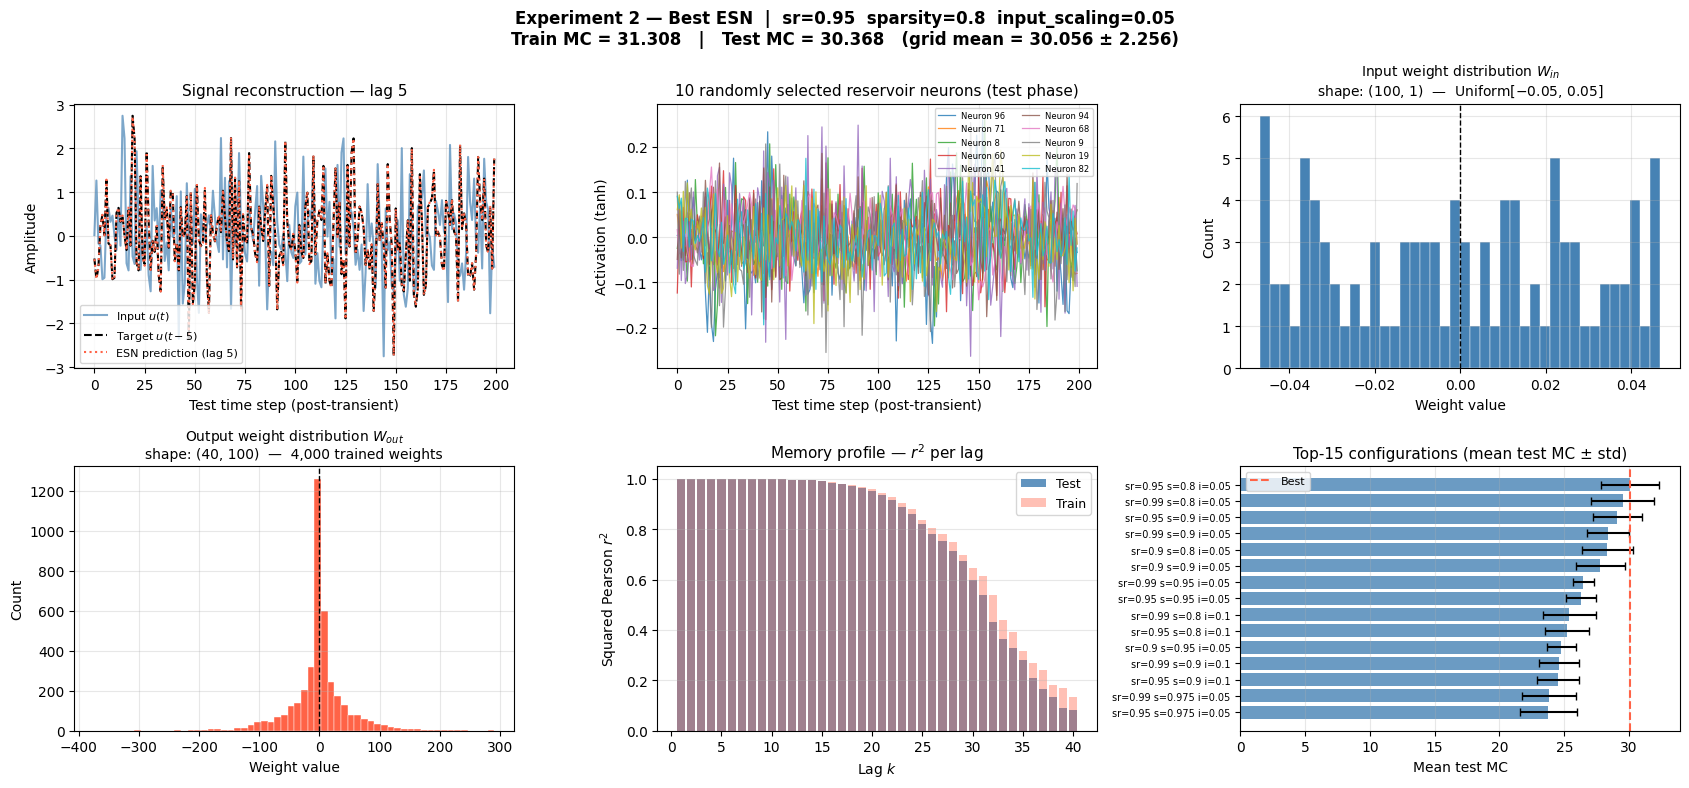

In [7]:
PLOT_SEED = 999   # held-out seed, not used during grid search

_, _, esn_best, W_in_best = evaluate_esn(
    spectral_radius   = best['spectral_radius'],
    sparsity          = best['sparsity'],
    input_scaling     = best['input_scaling'],
    data_seed         = PLOT_SEED,
    esn_seed          = PLOT_SEED,
    store_states      = True,
)

# Re-generate the same data split used for the plot run
X_plot, y_plot = generate_mc_data(SEQ_LEN, NUM_DELAYS, seed=PLOT_SEED)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_plot, y_plot, train_size=TRAIN_FRAC, shuffle=False
)
y_pred_test_p = esn_best.predict(X_test_p)

t = N_TRANSIENT
train_mc_best, train_r2_best = memory_capacity(
    y_train_p[t:], esn_best.training_prediction_[t:]
)
test_mc_best,  test_r2_best  = memory_capacity(
    y_test_p[t:],  y_pred_test_p[t:]
)
print(f'Best config (seed {PLOT_SEED})  →  train MC = {train_mc_best:.4f}  |  test MC = {test_mc_best:.4f}')

# ── Plot
neuron_idx = rng_global.choice(N_RESERVOIR, size=N_NEURONS_PLOT, replace=False)
time_axis  = np.arange(PLOT_WINDOW)
states_test = esn_best.states_pred_[t:]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle(
    f"Experiment 2 — Best ESN  |  "
    f"sr={best['spectral_radius']}  sparsity={best['sparsity']}  input_scaling={best['input_scaling']}\n"
    f"Train MC = {train_mc_best:.3f}   |   Test MC = {test_mc_best:.3f}   "
    f"(grid mean = {best['mean_test_mc']:.3f} ± {best['std_test_mc']:.3f})",
    fontsize=12, fontweight='bold'
)

# ── Panel 1: Signal reconstruction
ax = axes[0, 0]
ax.plot(time_axis, X_test_p[t:t + PLOT_WINDOW, 0],
        color='steelblue', lw=1.5, alpha=0.7, label='Input $u(t)$')
ax.plot(time_axis, y_test_p[t:t + PLOT_WINDOW, PLOT_LAG - 1],
        color='black', lw=1.5, linestyle='--',
        label=f'Target $u(t-{PLOT_LAG})$')
ax.plot(time_axis, y_pred_test_p[t:t + PLOT_WINDOW, PLOT_LAG - 1],
        color='tomato', lw=1.5, linestyle=':',
        label=f'ESN prediction (lag {PLOT_LAG})')
ax.set_title(f'Signal reconstruction — lag {PLOT_LAG}', fontsize=11)
ax.set_xlabel('Test time step (post-transient)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Panel 2: Neuron traces
ax = axes[0, 1]
cmap = plt.cm.tab10
for i, nidx in enumerate(neuron_idx):
    ax.plot(time_axis, states_test[:PLOT_WINDOW, nidx],
            lw=0.9, alpha=0.8, color=cmap(i % 10), label=f'Neuron {nidx}')
ax.set_title(f'{N_NEURONS_PLOT} randomly selected reservoir neurons (test phase)', fontsize=11)
ax.set_xlabel('Test time step (post-transient)')
ax.set_ylabel('Activation (tanh)')
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

# ── Panel 3: W_in distribution
ax = axes[0, 2]
ax.hist(W_in_best.flatten(), bins=40, color='steelblue',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_title('Input weight distribution $W_{in}$\n'
             f'shape: ({N_RESERVOIR}, 1)  —  Uniform[$-${best["input_scaling"]}, {best["input_scaling"]}]',
             fontsize=10)
ax.set_xlabel('Weight value')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# ── Panel 4: W_out distribution
ax = axes[1, 0]
n_wout = esn_best.W_out_.shape[0] * esn_best.W_out_.shape[1]
ax.hist(esn_best.W_out_.flatten(), bins=60, color='tomato',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', lw=1, linestyle='--')
ax.set_title('Output weight distribution $W_{out}$\n'
             f'shape: ({NUM_DELAYS}, {N_RESERVOIR})  —  {n_wout:,} trained weights',
             fontsize=10)
ax.set_xlabel('Weight value')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)

# ── Panel 5: Memory profile
ax = axes[1, 1]
lags = np.arange(1, NUM_DELAYS + 1)
ax.bar(lags, test_r2_best,  color='steelblue', alpha=0.85, label='Test')
ax.bar(lags, train_r2_best, color='tomato',    alpha=0.4,  label='Train')
ax.set_title('Memory profile — $r^2$ per lag', fontsize=11)
ax.set_xlabel('Lag $k$')
ax.set_ylabel('Squared Pearson $r^2$')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── Panel 6: Top-15 configurations
ax = axes[1, 2]
top15       = results[:15]
top15_means = [r['mean_test_mc'] for r in top15]
top15_stds  = [r['std_test_mc']  for r in top15]
top15_labels = [
    f"sr={r['spectral_radius']} s={r['sparsity']} i={r['input_scaling']}"
    for r in top15
]
y_pos = np.arange(len(top15))[::-1]   # best at top
ax.barh(y_pos, top15_means, xerr=top15_stds,
        color='steelblue', alpha=0.8, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15_labels, fontsize=7)
ax.axvline(best['mean_test_mc'], color='tomato', lw=1.5,
           linestyle='--', label='Best')
ax.set_title('Top-15 configurations (mean test MC ± std)', fontsize=11)
ax.set_xlabel('Mean test MC')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
#plt.savefig('/content/drive/MyDrive/experiment_2_results.png', dpi=150, bbox_inches='tight')
plt.show()